In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_exercise = pd.read_csv('../DATA/exercise.csv')
df_calories = pd.read_csv('../DATA/calories.csv')

In [3]:
df_exercise.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [4]:
df_calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [5]:
df = pd.merge(df_exercise, df_calories, how='inner')

In [6]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


## Пояснение к Данным
    1. User_ID - ID человека
    2. Gender - пол
    3. Age - возраст
    4. Height - рост
    5. Weight - вес
    6. Duration - длительность упражнений (в минутах)
    7. Heart_Rate - Удары в минуту (сердца)
    8. Body_Temp - температура тела
    9. Calories - вот это надо предсказать (сколько калорий сожжется)

## ВСЯ РАБОТА

In [7]:
df = df.drop('User_ID', axis=1)

In [8]:
df.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      15000 non-null  object 
 1   Age         15000 non-null  int64  
 2   Height      15000 non-null  float64
 3   Weight      15000 non-null  float64
 4   Duration    15000 non-null  float64
 5   Heart_Rate  15000 non-null  float64
 6   Body_Temp   15000 non-null  float64
 7   Calories    15000 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 937.6+ KB


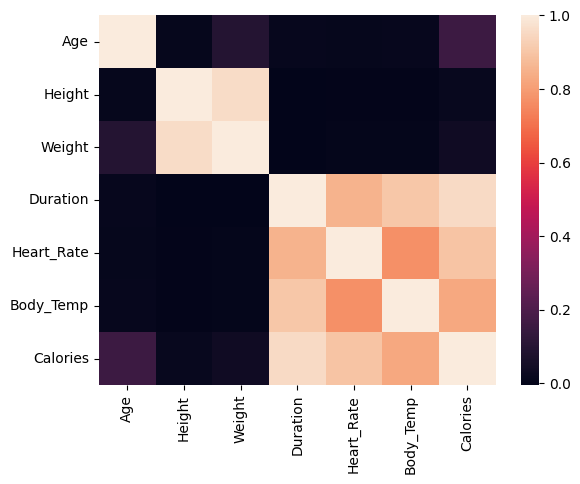

In [10]:
sns.heatmap(df.corr(numeric_only=True));

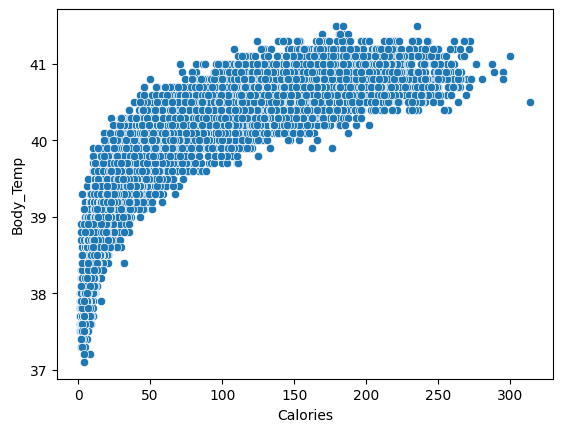

In [11]:
sns.scatterplot(x='Calories', y='Body_Temp', data=df);

In [12]:
df[df['Calories'] > 300]

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
428,male,75,199.0,103.0,28.0,123.0,40.5,314.0


In [13]:
df = df.drop(428)

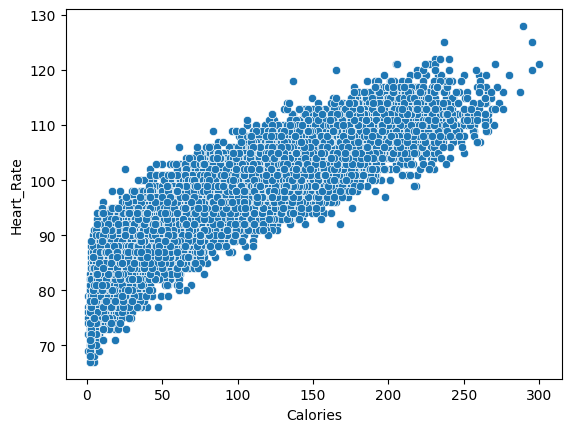

In [14]:
sns.scatterplot(x='Calories', y='Heart_Rate', data=df);

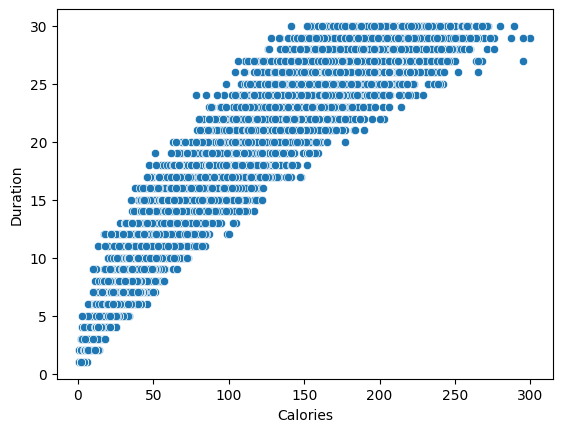

In [15]:
sns.scatterplot(x='Calories', y='Duration', data=df);

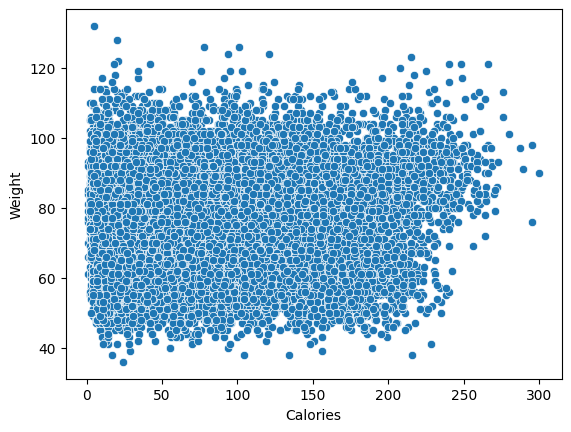

In [16]:
sns.scatterplot(x='Calories', y='Weight', data=df);

In [17]:
df[(df['Weight'] > 130) & (df['Calories'] < 50)]

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
6711,male,40,218.0,132.0,1.0,88.0,37.8,5.0


In [18]:
df = df.drop(6711)

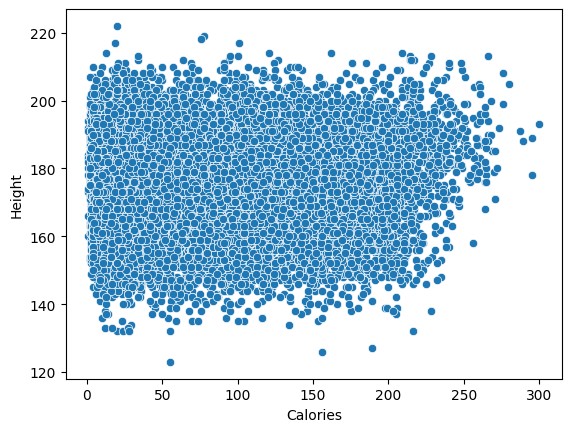

In [19]:
sns.scatterplot(x='Calories', y='Height', data=df);

In [20]:
df[df['Height'] < 130]

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
4200,female,63,123.0,40.0,9.0,97.0,39.9,55.0
6226,female,58,127.0,40.0,29.0,102.0,40.8,189.0
7774,female,30,126.0,39.0,25.0,104.0,40.7,156.0


In [21]:
df = df.drop([4200, 6226, 7774])

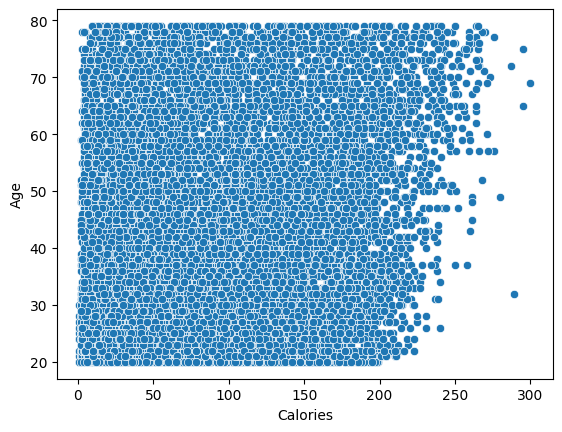

In [22]:
sns.scatterplot(x='Calories', y='Age', data=df);

In [23]:
df[(df['Calories'] > 270) & (df['Age'] < 40)]

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
9981,male,32,188.0,91.0,30.0,128.0,40.9,289.0


In [24]:
df = df.drop(9981)

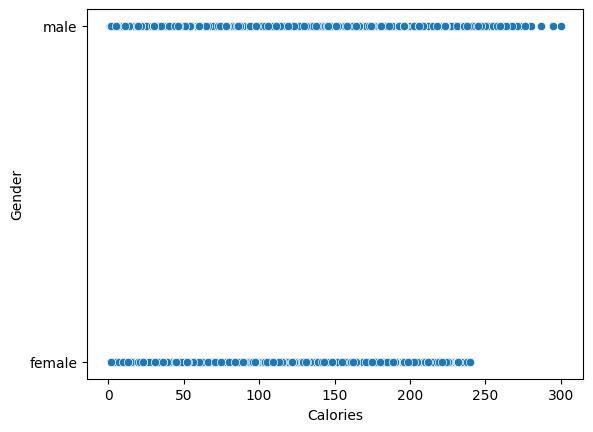

In [25]:
sns.scatterplot(x='Calories', y='Gender', data=df);

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

In [27]:
X = df.drop('Calories', axis=1)

In [28]:
y = df['Calories']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=104)

In [30]:
num_features = X_train.select_dtypes(exclude='object').columns.tolist()
cat_features = X_train.select_dtypes(include='object').columns.tolist()

In [31]:
num_features

['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

In [32]:
cat_features

['Gender']

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), num_features)
    ],
    remainder='passthrough'
)

In [34]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', ElasticNetCV(cv=10, l1_ratio=[.1, .5, .7, .9, .95, .99, 1], n_jobs=-1))
])

In [35]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [36]:
best_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_model.l1_ratio_}")

Лучшее значение alpha: 0.05972967390971265
Лучшее значение l1_ratio: 1.0


In [37]:
y_train_pred = pipe.predict(X_train)
y_pred = pipe.predict(X_test)

In [38]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)

In [39]:
MAE

2.251940023617992

In [40]:
MSE

9.476907874349287

In [41]:
RMSE

np.float64(3.078458684853394)

In [42]:
r2_train

0.9976143035825724

In [43]:
r2_test

0.997502312868259

In [44]:
df['Calories'].mean()

np.float64(89.50813658796852)

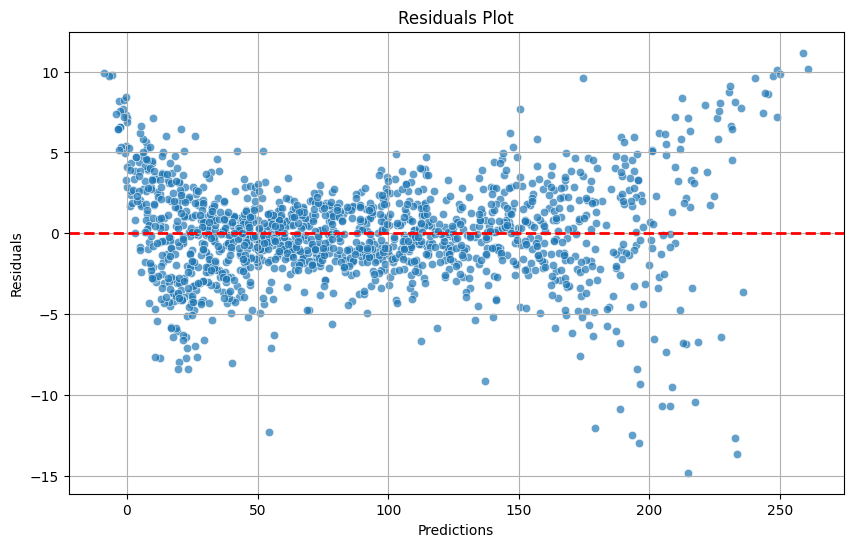

In [45]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)

plt.title('Residuals Plot')
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.grid(True)

In [46]:
pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [47]:
y_pred_full = pipe.predict(X)

In [48]:
best_final_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_final_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_final_model.l1_ratio_}")

Лучшее значение alpha: 0.06459075632464698
Лучшее значение l1_ratio: 0.99


In [49]:
r2_full = r2_score(y, y_pred_full)

In [50]:
r2_full

0.9975853212733796

In [51]:
my_fitness_df = pd.DataFrame({
    'Gender': ['female', 'male'],
    'Age': [68, 24],
    'Height': [162.0, 188.0],
    'Weight': [65.0, 95.0],
    'Duration': [8.0, 29.0],
    'Heart_Rate': [85.0, 135.0],
    'Body_Temp': [37.2, 40.8]
})

fitness_predictions = pipe.predict(my_fitness_df)
print(f"Пример 1 (Бабушка): {fitness_predictions[0]:.2f} ккал")
print(f"Пример 2 (Спортсмен): {fitness_predictions[1]:.2f} ккал")

Пример 1 (Бабушка): 27.02 ккал
Пример 2 (Спортсмен): 294.41 ккал


In [52]:
import json
import os

advanced_report = {
    "project": "Calories Burnt Prediction",
    "model": "ElasticNetCV",
    "trained_date": '2026-07',
    "test_parameters": {
        "alpha": best_model.alpha_,
        "l1_ratio": best_model.l1_ratio_,
        "cv": best_model.cv
    },
    "final_parameters": {
        "alpha": best_final_model.alpha_,
        "l1_ratio":  best_final_model.l1_ratio_,
        "cv": best_final_model.cv
    },
    "metrics": {
        "RMSE": RMSE,
        "MAE": MAE,
        "R2_train": r2_train,
        "R2_test": r2_test,
        "R2_full": r2_full,
        "Mean_Calories_Burnt": df['Calories'].mean()
    }
}


filename = "model_description.json"

with open(filename, "w", encoding="utf-8") as f:
    json.dump(advanced_report, f, indent=4, ensure_ascii=False)

In [53]:
from joblib import dump, load

In [54]:
dump(pipe, 'model/calories_burnt_predictions_elastic_net_cv_2026_v1.pkl')

['model/calories_burnt_predictions_elastic_net_cv_2026_v1.pkl']

In [55]:
loaded_pipe = load('model/calories_burnt_predictions_elastic_net_cv_2026_v1.pkl')

In [56]:
loaded_pipe.predict(my_fitness_df)

array([ 27.01584897, 294.40785466])